# Online Recruitment Fraud Detection - Machine Learning Baselines
This notebook implements the traditional Machine Learning baselines (Logistic Regression and Random Forest) using TF-IDF features on the EMSCAD dataset.

### State-of-the-Art Enhancements Included:
1. **Structured Text Concatenation**: Concatenates multiple textual fields with clear prepended labels (`Title: ... | Company Profile: ... | Description: ...`) to preserve structural boundaries for feature extraction.
2. **Stratified Splits**: Ensures exact class ratio preservation across Train, Validation, and Test sets.
3. **Consolidated Evaluation**: Prints a publication-ready metrics summary (Accuracy, Precision, Recall, F1-Score, and ROC-AUC) for easy comparison.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

csv_path = "fake_job_postings.csv"

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Dataset 'fake_job_postings.csv' not found. Please upload it:")
        uploaded = files.upload()
    except ImportError:
        print(f"Local file '{csv_path}' not found. Please place it in the same directory.")
else:
    print(f"Dataset found at '{csv_path}'. Skipping upload prompt.")

Dataset found at 'fake_job_postings.csv'. Skipping upload prompt.


## Load and Preprocess Dataset (Structured Concatenation)

In [5]:
print("Loading dataset...")
df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")

# Fill missing values with empty space
df.fillna(" ", inplace=True)

# Structured field concatenation to preserve contextual text boundaries (10 fields)
df['combined_text'] = (
    "Title: " + df['title'].astype(str) + 
    " | Company Profile: " + df['company_profile'].astype(str) + 
    " | Description: " + df['description'].astype(str) + 
    " | Requirements: " + df['requirements'].astype(str) + 
    " | Benefits: " + df['benefits'].astype(str) + 
    " | Employment Type: " + df['employment_type'].astype(str) + 
    " | Required Experience: " + df['required_experience'].astype(str) + 
    " | Required Education: " + df['required_education'].astype(str) + 
    " | Industry: " + df['industry'].astype(str) + 
    " | Function: " + df['function'].astype(str)
)

# Print class distribution
print("Class distribution (0 = Genuine, 1 = Fraudulent):")
print(df['fraudulent'].value_counts(normalize=True))

Loading dataset...
Dataset shape: (17880, 18)
Class distribution (0 = Genuine, 1 = Fraudulent):
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


## Train/Test Split (Stratified)

In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['fraudulent'], random_state=42
)
print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 14304
Test set size: 3576


## TF-IDF Feature Extraction

In [7]:
print("Vectorizing text using TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train_df['combined_text'])
X_test = vectorizer.transform(test_df['combined_text'])
y_train = train_df['fraudulent'].values
y_test = test_df['fraudulent'].values
print("TF-IDF shape:", X_train.shape)

Vectorizing text using TF-IDF...
TF-IDF shape: (14304, 5000)


## 1. Logistic Regression

In [8]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

Training Logistic Regression...


## 2. Random Forest

In [9]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

Training Random Forest...


## Formatted Performance Summary & Plotting

--- LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.62      0.89      0.73       173

    accuracy                           0.97      3576
   macro avg       0.81      0.93      0.86      3576
weighted avg       0.98      0.97      0.97      3576

--- RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.55      0.71       173

    accuracy                           0.98      3576
   macro avg       0.99      0.78      0.85      3576
weighted avg       0.98      0.98      0.98      3576


================ PUBLICATION METRICS SUMMARY ================
Metric          | Logistic Regression  | Random Forest       
---------------------------------------------------------------
Accuracy        | 96.84              % | 97.85              %
Precision       | 62.10              % | 100.

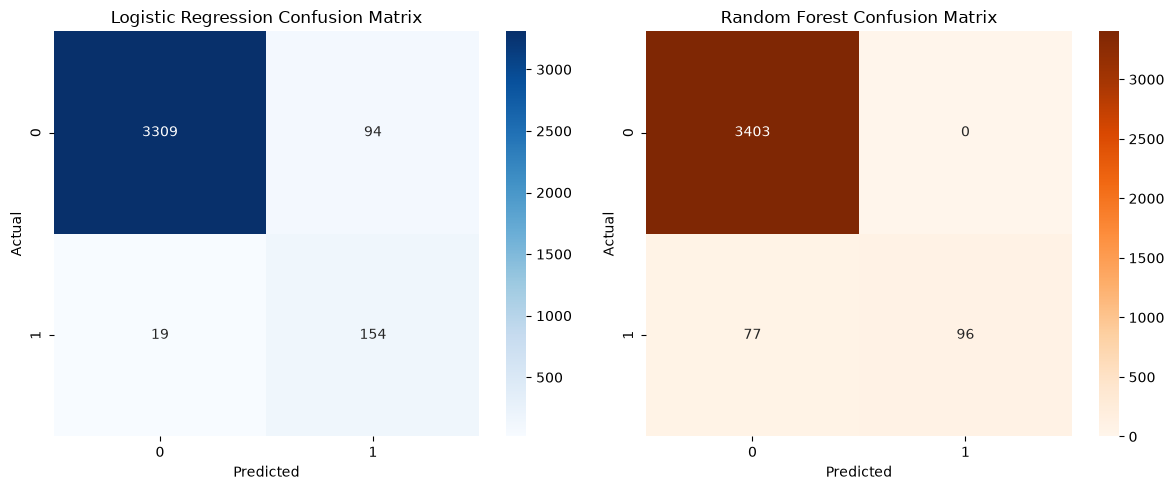

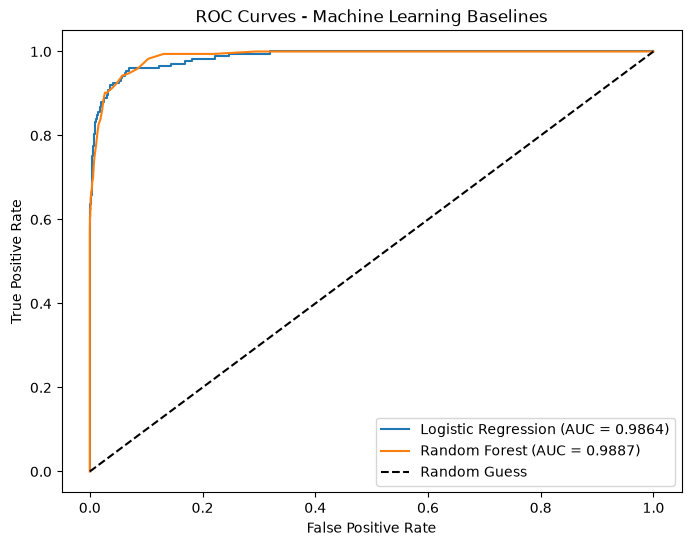

In [ ]:
print("--- LOGISTIC REGRESSION ---")
print(classification_report(y_test, lr_preds))

print("--- RANDOM FOREST ---")
print(classification_report(y_test, rf_preds))

# Consolidated Metric Display
lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds)
lr_rec = recall_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print("\n================ PUBLICATION METRICS SUMMARY ================")
print(f"{ 'Metric':<15} | {'Logistic Regression':<20} | {'Random Forest':<20}")
print("-"*63)
print(f"{ 'Accuracy':<15} | {lr_acc*100:<19.2f}% | {rf_acc*100:<19.2f}%")
print(f"{ 'Precision':<15} | {lr_prec*100:<19.2f}% | {rf_prec*100:<19.2f}%")
print(f"{ 'Recall':<15} | {lr_rec*100:<19.2f}% | {rf_rec*100:<19.2f}%")
print(f"{ 'F1-Score':<15} | {lr_f1*100:<19.2f}% | {rf_f1*100:<19.2f}%")
print(f"{ 'ROC-AUC':<15} | {lr_auc*100:<19.2f}% | {rf_auc*100:<19.2f}%")
print("=============================================================")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Plot ROC Curves
plt.figure(figsize=(8, 6))
for name, probs in [("Logistic Regression", lr_probs), ("Random Forest", rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Machine Learning Baselines')
plt.legend(loc='lower right')
plt.show()